Mainly followed from [https://github.com/eugenet12/pytorch-rbm-autoencoder](https://github.com/eugenet12/pytorch-rbm-autoencoder)

In [40]:
import os
import sys
import random

import yaml

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision

from torchvision.utils import make_grid
from torchvision import transforms

from torch.autograd import Variable

from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision.datasets import MNIST

from torchinfo import summary

from huggingface_hub import hf_hub_download

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_olivetti_faces

# tell jupyter where are local modules are
module_path = os.path.abspath('.')
if module_path not in sys.path:
    sys.path.append(module_path)

### 1. Get available device

In [41]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        try:
            _ = torch.zeros(1, device="mps")
            return torch.device("mps")
        except Exception:
            pass
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

Using device: mps


### 2. Util functions

In [42]:
"""A set of generically helpful utility methods and constants"""

def seed_everything(seed=42):
    """Seed everything to make the code more reproducable.

    This code is the same as that found from many public Kaggle kernels.

    Parameters
    ----------
    seed: int
        seed value to ues

    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

### 3. Deep autoencoder (DAE) and naive DAE

#### 3.1 Vanilla autoencoder (AE)

In [43]:
class AE(nn.Module):
    """ A standard implementation of the deep autoencoder without pretraining. """

    def __init__(self, layers):
        """ parameter of layers: list[int], the number of dimensions in each layer of the vanilla AE. """
        super(AE, self).__init__()

        self.layers = layers
        encoders = []
        decoders = []
        prev_layer = layers[0]
        for layer in layers[1:]:
            encoders.append(nn.Linear(in_features=prev_layer, out_features=layer))
            decoders.append(nn.Linear(in_features=layer, out_features=prev_layer))
            prev_layer = layer
        self.encoders = nn.ModuleList(encoders)
        self.decoders = nn.ModuleList(reversed(decoders))

    def forward(self, x):
        """ forward step returns a reconstructed version of x """
        z = self.encode(x)
        x_prime = self.decode(z)
        return x_prime

    def encode(self, x):
        """ encode the input x. it returns encoded input """
        for i, enc in enumerate(self.encoders):
            if i == len(self.encoders) - 1:
                x = enc(x)
            else:
                x = torch.sigmoid(enc(x))
        return x
    
    def decode(self, x):
        """ decode the representation x. it returns decoded input """
        for dec in self.decoders:
            x = torch.sigmoid(dec(x))
        return x

In the paper, it says: 
*We also used a 625-2000-1000-500-30 autoencoder with linear input units to discover 30 dimensional codes for grayscale image patches  that were derived from the livetti face data set*.

In [44]:
data = fetch_olivetti_faces(shuffle=True, random_state=0)  # downloads if needed
images = data.images        # (400, 64, 64), float in [0,1]
labels = data.target        # (400,)
print(len(images), images[0].size, len(labels), len(set(labels)))

400 4096 400 40


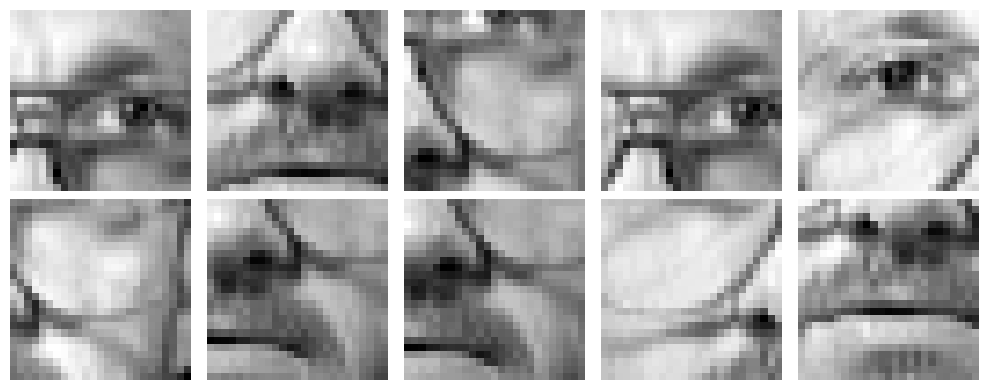

(20000, 625) (20000,) 0 39


In [63]:
def show_patches_2x5(X, patch_h, patch_w, start=0):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.ravel()

    for i in range(10):
        patch = X[start + i].reshape(patch_h, patch_w)
        axes[i].imshow(patch, cmap="gray")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()
    
patch_h = patch_w = 25
patches_per_image = 50
rng = np.random.default_rng(42)

patches = []
patch_labels = []

for img, person_id in zip(images, labels):
    for _ in range(patches_per_image):
        r = rng.integers(0, 64 - patch_h + 1)
        c = rng.integers(0, 64 - patch_w + 1)
        patch = img[r:r+patch_h, c:c+patch_w]        # (25,25)
        patches.append(patch.reshape(-1))            # (625,)
        patch_labels.append(person_id)               # 0..39

show_patches_2x5(X, patch_h, patch_w, start=0)
X = np.stack(patches).astype(np.float32)             # (N,625)
y = np.array(patch_labels, dtype=np.int64)           # (N,)
print(X.shape, y.shape, y.min(), y.max())


In [67]:
perm = rng.permutation(len(X))
per_img_size = patch_h * patch_w
batch_size = 64

val_ratio = 0.1
n_val = int(len(X) * val_ratio)
val_idx, train_idx = perm[:n_val], perm[n_val:]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [ ]:
vanilla_ae = AE([per_img_size, 2000, 1000, 500, 30])
summary(vanilla_ae, input_size=(batch_size, per_img_size), device=str(DEVICE))

lr = 5e-4
loss = nn.MSELoss()
optimizer = optim.Adam(vanilla_ae.parameters(), lr)
num_epochs = 500
dim1, dim2= 25, 25
# train
running_loss = float("inf")
for epoch in range(num_epochs):
    losses = []
    for i, data_list in enumerate(train_dl):
        x = data_list[0].to(DEVICE)
        x_hat = vanilla_ae(x)
        batch_loss = loss(x, x_hat)
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
        losses.append(batch_loss.item())
    running_loss = np.mean(losses)
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch}: {running_loss}")
    if (epoch + 1) % 80 == 0:
        img0 = make_grid(x.view(x.shape[0], 1, dim1, dim2).detach().cpu())
        np0  = np.transpose(img0.numpy(), (1, 2, 0))
        img1 = make_grid(x_hat.view(x_hat.shape[0], 1, dim1, dim2).detach().cpu())
        np1  = np.transpose(img1.numpy(), (1, 2, 0))
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        axes[0].imshow(np0)
        axes[0].set_title("Original MNIST images")
        axes[0].axis("off")
        
        axes[1].imshow(np1)
        axes[1].set_title("Reconstructed MNIST images")
        axes[1].axis("off")
        
        plt.tight_layout()
        plt.show()

#### 3.2 Deep autoencoder with RBMs as pretraining

In [6]:
class DAE(nn.Module):
    """A Deep Autoencoder that takes a list of RBMs as input"""

    def __init__(self, models):
        """Create a deep autoencoder based on a list of RBM models

        Parameters
        ----------
        models: list[RBM]
            a list of RBM models to use for autoencoding
        """
        super(DAE, self).__init__()

        # extract weights from each model
        encoders = []
        encoder_biases = []
        decoders = []
        decoder_biases = []
        for model in models:
            encoders.append(nn.Parameter(model.W.clone()))
            encoder_biases.append(nn.Parameter(model.h_bias.clone()))
            decoders.append(nn.Parameter(model.W.clone()))
            decoder_biases.append(nn.Parameter(model.v_bias.clone()))

        # build encoders and decoders
        self.encoders = nn.ParameterList(encoders)
        self.encoder_biases = nn.ParameterList(encoder_biases)
        self.decoders = nn.ParameterList(reversed(decoders))
        self.decoder_biases = nn.ParameterList(reversed(decoder_biases))

    def forward(self, v):
        """ Forward step returns a reconstruction of v from the autoencoder """
        p_h = self.encode(v) # encode
        p_v = self.decode(p_h) # decode
        return p_v

    def encode(self, v):  # for visualization, encode without sigmoid
        """encode returns the activations of the last layer of the encoder """
        p_v = v
        for i in range(len(self.encoders)):
            activation = torch.mm(p_v, self.encoders[i]) + self.encoder_biases[i]
            p_v = torch.sigmoid(activation)
        return activation # return the activation directly rather than the sigmoid

    def decode(self, h):
        """decode returns reconstruction of original input based on h """
        p_h = h
        for i in range(len(self.encoders)):
            activation = torch.mm(p_h, self.decoders[i].t()) + self.decoder_biases[i]
            p_h = torch.sigmoid(activation)
        return p_h

### 4. Restricted Boltzmann Machine (RBM) and train RBM

In [18]:
"""Implementation of a Restricted Boltzmann Machine"""
class RBM():
    """Implementation of a Restricted Boltzmann Machine
    
    Note that this implementation does not use Pytorch's nn.Module
    because we are updating the weights ourselves

    """
    def __init__(self, visible_dim, hidden_dim, gaussian_hidden_distribution=False, device=None):
        """Initialize a Restricted Boltzmann Machine

        Parameters
        ----------
        visible_dim: int
            number of dimensions in visible (input) layer
        hidden_dim: int
            number of dimensions in hidden layer
        gaussian_hidden_distribution: bool
            whether to use a Gaussian distribution for the values of the hidden dimension instead of a Bernoulli

        """
        self.visible_dim = visible_dim
        self.hidden_dim = hidden_dim
        self.gaussian_hidden_distribution = gaussian_hidden_distribution

        self.device = device if device is not None else torch.device("cpu")

        # intialize parameters
        self.W = torch.randn(visible_dim, hidden_dim).to(self.device) * 0.1
        self.h_bias = torch.zeros(hidden_dim).to(self.device)  # v --> h
        self.v_bias = torch.zeros(visible_dim).to(self.device)  # h --> v

        # parameters for learning with momentum
        self.W_momentum = torch.zeros(visible_dim, hidden_dim).to(self.device)
        self.h_bias_momentum = torch.zeros(hidden_dim).to(self.device)  # v --> h
        self.v_bias_momentum = torch.zeros(visible_dim).to(self.device)  # h --> v

    def sample_h(self, v):
        """Get sample hidden values and activation probabilities

        Parameters
        ----------
        v: Tensor
            tensor of input from visible layer

        """
        v = v.to(self.device)  # ensure same device
        activation = torch.mm(v, self.W) + self.h_bias
        if self.gaussian_hidden_distribution:
            h_sample = activation + torch.randn_like(activation)
            return activation, h_sample
        else:
            p = torch.sigmoid(activation)
            return p, torch.bernoulli(p)

    def sample_v(self, h):
        """Get visible activation probabilities

        Parameters
        ----------
        h: Tensor
            tensor of input from hidden

        """
        activation = torch.mm(h, self.W.t()) + self.v_bias
        p = torch.sigmoid(activation)
        return p

    def update_weights(self, v0, vk, ph0, phk, lr, momentum_coef, weight_decay, batch_size):
        """Learning step: update parameters 

        Uses contrastive divergence algorithm as described in

        Parameters
        ----------
        v0: Tensor
            initial visible state
        vk: Tensor
            final visible state
        ph0: Tensor
            hidden activation probabilities for v0
        phk: Tensor
            hidden activation probabilities for vk
        lr: float
            learning rate
        momentum_coef: float
            coefficient to use for momentum
        weight_decay: float
            coefficient to use for weight decay
        batch_size: int
            size of each batch

        """
        self.W_momentum *= momentum_coef
        self.W_momentum += torch.mm(v0.t(), ph0) - torch.mm(vk.t(), phk)

        self.h_bias_momentum *= momentum_coef
        self.h_bias_momentum += torch.sum((ph0 - phk), 0)

        self.v_bias_momentum *= momentum_coef
        self.v_bias_momentum += torch.sum((v0 - vk), 0)

        self.W += lr*self.W_momentum/batch_size
        self.h_bias += lr*self.h_bias_momentum/batch_size
        self.v_bias += lr*self.v_bias_momentum/batch_size

        self.W -= self.W * weight_decay # L2 weight decay

In [19]:
def train_rbm(train_dl, visible_dim, hidden_dim, k, num_epochs, lr, use_gaussian=False, device=None):
    """Create and train an RBM
    
    Uses a custom strategy to have 0.5 momentum before epoch 5 and 0.9 momentum after
    
    Parameters
    ----------
    train_dl: DataLoader
        training data loader
    visible_dim: int
        number of dimensions in visible (input) layer
    hidden_dim: int
        number of dimensions in hidden layer
    k: int
        number of iterations to run for Gibbs sampling (often 1 is used)
    num_epochs: int
        number of epochs to run for
    lr: float
        learning rate
    use_gaussian:
        whether to use a Gaussian distribution for the hidden state
    
    Returns
    -------
    RBM, Tensor, Tensor
        a trained RBM model, sample input tensor, reconstructed activation probabilities for sample input tensor

    """
    rbm = RBM(visible_dim=visible_dim, hidden_dim=hidden_dim, gaussian_hidden_distribution=use_gaussian, device=device)
    loss = torch.nn.MSELoss() # we will use MSE loss

    for epoch in range(num_epochs):
        train_loss = 0
        for i, data_list in enumerate(train_dl):
            sample_data = data_list[0].to(DEVICE)
            v0, pvk = sample_data, sample_data
            
            # Gibbs sampling
            for i in range(k):
                _, hk = rbm.sample_h(pvk)
                pvk = rbm.sample_v(hk)
            
            # compute ph0 and phk for updating weights
            ph0, _ = rbm.sample_h(v0)
            phk, _ = rbm.sample_h(pvk)
            
            # update weights
            rbm.update_weights(v0, pvk, ph0, phk, lr, 
                               momentum_coef=0.5 if epoch < 5 else 0.9, 
                               weight_decay=2e-4, 
                               batch_size=sample_data.shape[0])

            # track loss
            train_loss += loss(v0, pvk)
        
        # print training loss
        print(f"epoch {epoch}: {train_loss/len(train_dl)}")
    return rbm, v0, pvk

### 5. Prepare MNIST data and train AEs

In [10]:
repo_id = "dmitva/the-mnist-database"
files = [
    "train-images.idx3-ubyte",
    "train-labels.idx1-ubyte",
    "t10k-images.idx3-ubyte",
    "t10k-labels.idx1-ubyte",
]

local_paths = [
    hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=f)
    for f in files
]
for local_path in local_paths:
    print(local_path)

mnist_dir = os.path.dirname(local_path)

/Users/baojianzhou/.cache/huggingface/hub/datasets--dmitva--the-mnist-database/snapshots/7f936b52eb9730084a2b45ded636f6b90aabf30b/train-images.idx3-ubyte
/Users/baojianzhou/.cache/huggingface/hub/datasets--dmitva--the-mnist-database/snapshots/7f936b52eb9730084a2b45ded636f6b90aabf30b/train-labels.idx1-ubyte
/Users/baojianzhou/.cache/huggingface/hub/datasets--dmitva--the-mnist-database/snapshots/7f936b52eb9730084a2b45ded636f6b90aabf30b/t10k-images.idx3-ubyte
/Users/baojianzhou/.cache/huggingface/hub/datasets--dmitva--the-mnist-database/snapshots/7f936b52eb9730084a2b45ded636f6b90aabf30b/t10k-labels.idx1-ubyte


In [13]:
raw = Path(Path(mnist_dir)) / "MNIST" / "raw"
raw.mkdir(parents=True, exist_ok=True)

name_map = {
    "train-images.idx3-ubyte": "train-images-idx3-ubyte",
    "train-labels.idx1-ubyte": "train-labels-idx1-ubyte",
    "t10k-images.idx3-ubyte":  "t10k-images-idx3-ubyte",
    "t10k-labels.idx1-ubyte":  "t10k-labels-idx1-ubyte",
}

for src_name, dst_name in name_map.items():
    src = Path(mnist_dir) / src_name
    dst = raw / dst_name
    if dst.exists() or dst.is_symlink():
        dst.unlink()
    dst.symlink_to(src)

print("Torchvision MNIST raw folder:", raw)
print("Files:", sorted([p.name for p in raw.iterdir()]))

Torchvision MNIST raw folder: /Users/baojianzhou/.cache/huggingface/hub/datasets--dmitva--the-mnist-database/snapshots/7f936b52eb9730084a2b45ded636f6b90aabf30b/MNIST/raw
Files: ['t10k-images-idx3-ubyte', 't10k-labels-idx1-ubyte', 'train-images-idx3-ubyte', 'train-labels-idx1-ubyte']


In [15]:
seed_everything(42)
MNIST_NUM_PIXELS = 784 # 28x28

transform = transforms.Compose([
    transforms.ToTensor(),                 # (1,28,28), float in [0,1]
    transforms.Lambda(lambda x: x.view(-1)) # (784,)
])

train_ds = MNIST(root=str(mnist_dir), train=True, download=False, transform=transform)
test_ds  = MNIST(root=str(mnist_dir), train=False, download=False, transform=transform)

train_dl_flat = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl_flat  = DataLoader(test_ds, batch_size=64, shuffle=False)
print(train_ds, test_ds)

Dataset MNIST
    Number of datapoints: 60000
    Root location: /Users/baojianzhou/.cache/huggingface/hub/datasets--dmitva--the-mnist-database/snapshots/7f936b52eb9730084a2b45ded636f6b90aabf30b
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Lambda()
           ) Dataset MNIST
    Number of datapoints: 10000
    Root location: /Users/baojianzhou/.cache/huggingface/hub/datasets--dmitva--the-mnist-database/snapshots/7f936b52eb9730084a2b45ded636f6b90aabf30b
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Lambda()
           )


### 6. Naive Deep Autoencoder

A naive training of the autoencoder does a very poor job and gets stuck at a generic implementation!

Epoch 0: 0.06812436634035253
Epoch 1: 0.06749842325841059
Epoch 2: 0.05567074068256024
Epoch 3: 0.04924674502520292
Epoch 4: 0.04770893895867537


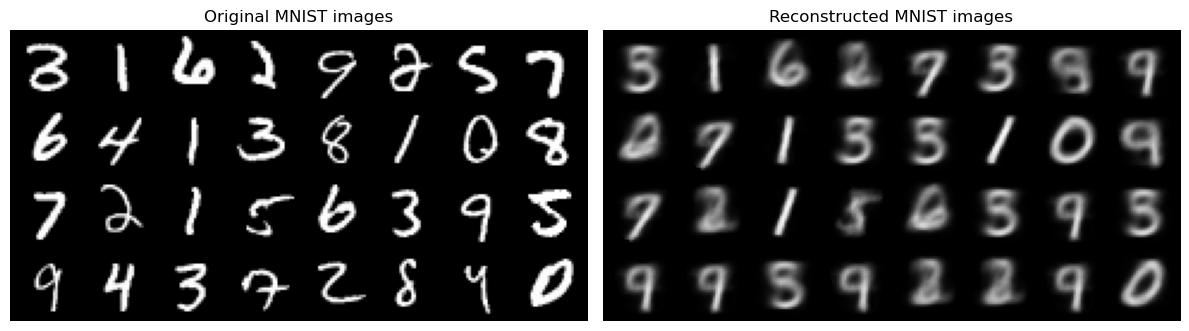

Epoch 5: 0.04667260444987176
Epoch 6: 0.04614306452161849
Epoch 7: 0.045619247779091286
Epoch 8: 0.045220055833840166
Epoch 9: 0.04496485800710696


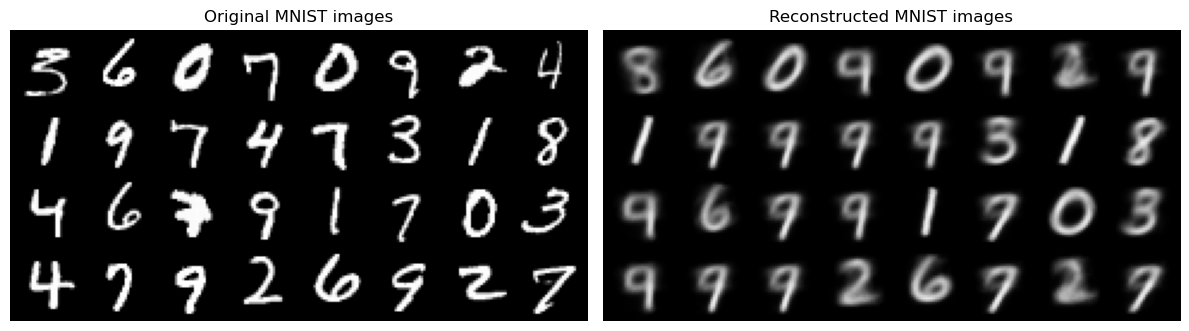

Epoch 10: 0.04470578009195165
Epoch 11: 0.04440621734618632
Epoch 12: 0.043979496411137235
Epoch 13: 0.042827779665462244
Epoch 14: 0.04200600634918793


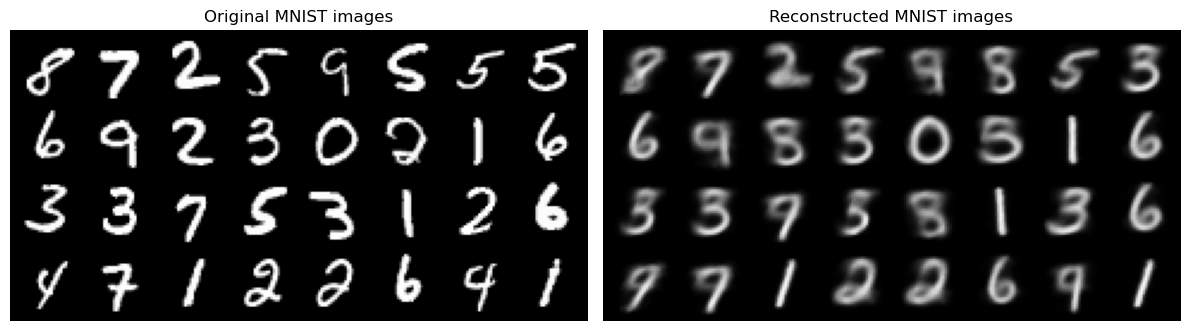

Epoch 15: 0.041246327704616954
Epoch 16: 0.04001495131710445
Epoch 17: 0.038901267112540536
Epoch 18: 0.03831551508950209
Epoch 19: 0.03769949648076537


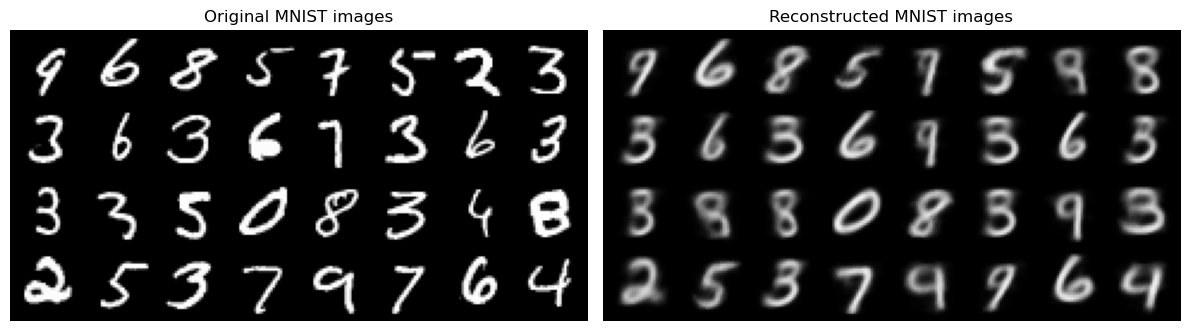

In [16]:
# fine-tune autoencoder
lr = 1e-3
vanilla_ae = AE([784,1000,500,250,2]).to(DEVICE)
loss = nn.MSELoss()
optimizer = optim.Adam(vanilla_ae.parameters(), lr)
num_epochs = 20
dim1, dim2= 28, 28

# train
running_loss = float("inf")
for epoch in range(num_epochs):
    losses = []
    for i, data_list in enumerate(train_dl_flat):
        data = data_list[0].to(DEVICE)
        
        v_pred = vanilla_ae(data)
        batch_loss = loss(data, v_pred) # difference between actual and reconstructed   
        losses.append(batch_loss.item())
        
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
    running_loss = np.mean(losses)
    print(f"Epoch {epoch}: {running_loss}")
    if (epoch + 1) % 5 == 0:
        img0 = make_grid(data.view(data.shape[0], 1, dim1, dim2).detach().cpu())
        np0  = np.transpose(img0.numpy(), (1, 2, 0))
        img1 = make_grid(v_pred.view(v_pred.shape[0], 1, dim1, dim2).detach().cpu())
        np1  = np.transpose(img1.numpy(), (1, 2, 0))
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        axes[0].imshow(np0)
        axes[0].set_title("Original MNIST images")
        axes[0].axis("off")
        
        axes[1].imshow(np1)
        axes[1].set_title("Reconstructed MNIST images")
        axes[1].axis("off")
        
        plt.tight_layout()
        plt.show()

### 7. Train RBMs

784 -> 1000
epoch 0: 0.015581527724862099
epoch 1: 0.010490957647562027
epoch 2: 0.009785854257643223
epoch 3: 0.00945025123655796
epoch 4: 0.009202824905514717
epoch 5: 0.01005573384463787
epoch 6: 0.009332714602351189
epoch 7: 0.009000607766211033
epoch 8: 0.008806654252111912
epoch 9: 0.008660644292831421


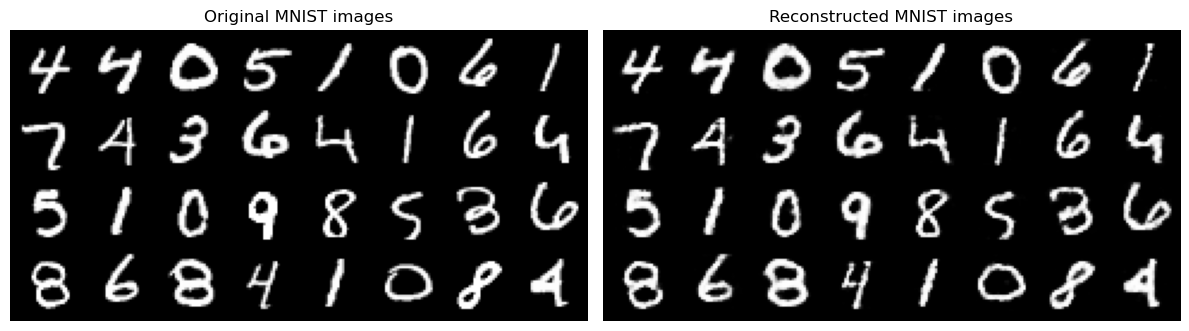

1000 -> 500
epoch 0: 0.017253275960683823
epoch 1: 0.010708452202379704
epoch 2: 0.009451468475162983
epoch 3: 0.008644507266581059
epoch 4: 0.008071818388998508
epoch 5: 0.007722882088273764
epoch 6: 0.006573266349732876
epoch 7: 0.006076853722333908
epoch 8: 0.005862839985638857
epoch 9: 0.005746170878410339


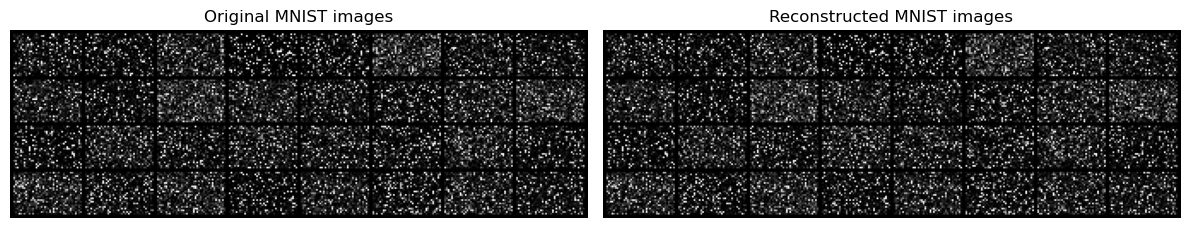

500 -> 250
epoch 0: 0.021832184866070747
epoch 1: 0.013502709567546844
epoch 2: 0.012352347373962402
epoch 3: 0.011767653748393059
epoch 4: 0.01136728748679161
epoch 5: 0.011788742616772652
epoch 6: 0.011083343997597694
epoch 7: 0.010717484168708324
epoch 8: 0.010484868660569191
epoch 9: 0.010329160839319229


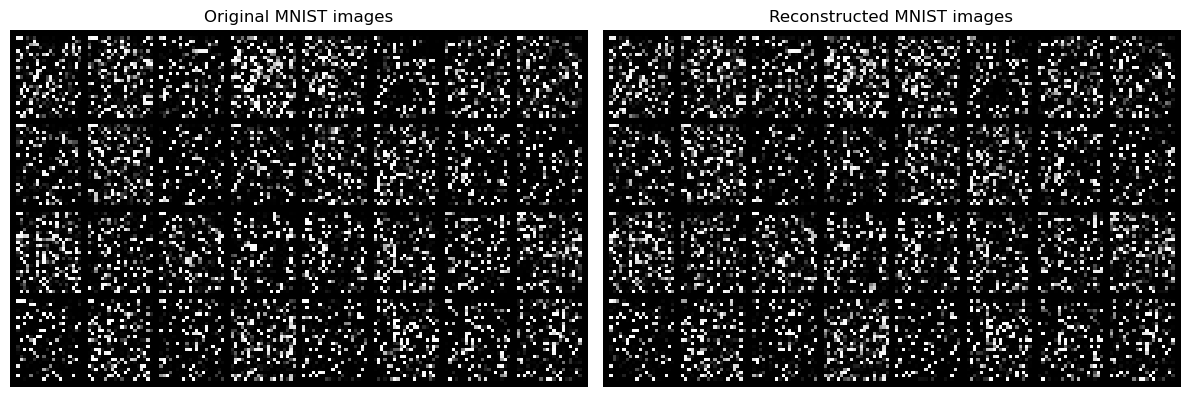

250 -> 2
epoch 0: 0.16618382930755615
epoch 1: 0.14372770488262177
epoch 2: 0.13700823485851288
epoch 3: 0.13417936861515045
epoch 4: 0.13271141052246094
epoch 5: 0.13114029169082642
epoch 6: 0.13037170469760895
epoch 7: 0.1302545815706253
epoch 8: 0.13021346926689148
epoch 9: 0.13021983206272125
epoch 10: 0.13021454215049744
epoch 11: 0.13021495938301086
epoch 12: 0.13021115958690643
epoch 13: 0.1302095353603363
epoch 14: 0.1302054524421692
epoch 15: 0.13019265234470367
epoch 16: 0.13020619750022888
epoch 17: 0.13020816445350647
epoch 18: 0.13020457327365875
epoch 19: 0.13018423318862915
epoch 20: 0.13020390272140503
epoch 21: 0.13020870089530945
epoch 22: 0.13019217550754547
epoch 23: 0.13020522892475128
epoch 24: 0.13019876182079315
epoch 25: 0.13020506501197815
epoch 26: 0.13019129633903503
epoch 27: 0.13020166754722595
epoch 28: 0.1302015334367752
epoch 29: 0.1302078366279602


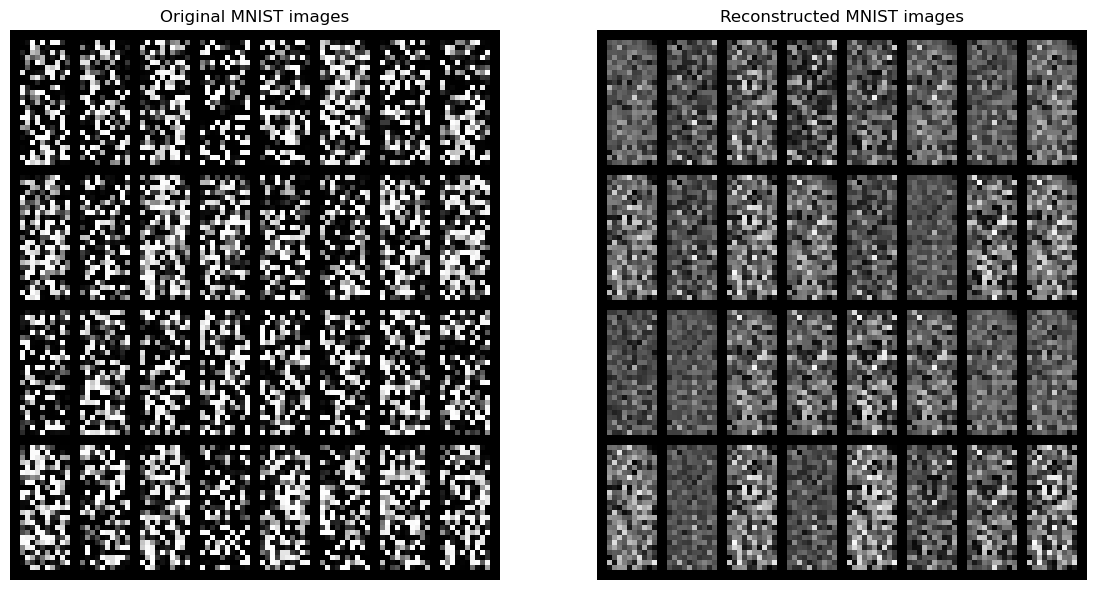

In [20]:
with open("config-rbm.yaml", "r") as f:
    cfg = yaml.safe_load(f)
hidden_dimensions = cfg["hidden_dimensions"]

new_train_dl = train_dl_flat

visible_dim = MNIST_NUM_PIXELS
models = []

for configs in hidden_dimensions:
    hidden_dim   = configs["hidden_dim"]
    num_epochs   = configs["num_epochs"]
    lr           = configs["learning_rate"]
    d1           = configs["display_dim1"]
    d2           = configs["display_dim2"]
    use_gaussian = configs["use_gaussian"]

    print(f"{visible_dim} -> {hidden_dim}")

    # Train RBM, assumes train_rbm internally moves batches/model correctly
    model, v, v_pred = train_rbm(
        new_train_dl,
        visible_dim,
        hidden_dim, k=1, num_epochs=num_epochs,lr=lr, use_gaussian=use_gaussian, device=DEVICE)
    models.append(model)

    # Display (make sure display_output expects CPU tensors)
    img0 = make_grid(v.view(v.shape[0], 1, d1, d2).detach().cpu())
    np0  = np.transpose(img0.numpy(), (1, 2, 0))
    img1 = make_grid(v_pred.view(v_pred.shape[0], 1, d1, d2).detach().cpu())
    np1  = np.transpose(img1.numpy(), (1, 2, 0))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(np0)
    axes[0].set_title("Original MNIST images")
    axes[0].axis("off")
    
    axes[1].imshow(np1)
    axes[1].set_title("Reconstructed MNIST images")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

    new_data = []
    for data_list in new_train_dl:
        p = model.sample_h(data_list[0].to(DEVICE))[0]
        new_data.append(p.detach().cpu().numpy())
    new_input = np.concatenate(new_data)
    new_train_dl = DataLoader(
        TensorDataset(torch.Tensor(new_input).to(DEVICE)), 
        batch_size=64, 
        shuffle=False
    )
    
    # update new visible_dim for next RBM
    visible_dim = hidden_dim

### 8. Fine-tune Deep Autoencoder from built from RBMs

Epoch 0: 0.04527011837786449
Epoch 1: 0.03904011926409214
Epoch 2: 0.03743088724357741
Epoch 3: 0.036422168615577954
Epoch 4: 0.03571042863489277


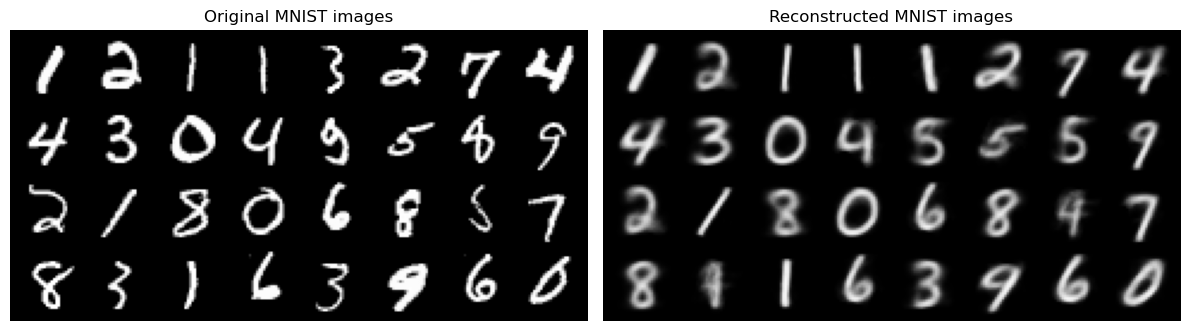

Epoch 5: 0.03505693691403373
Epoch 6: 0.03457228832447262
Epoch 7: 0.03433239103149948
Epoch 8: 0.03382935417271944
Epoch 9: 0.03359279703539508


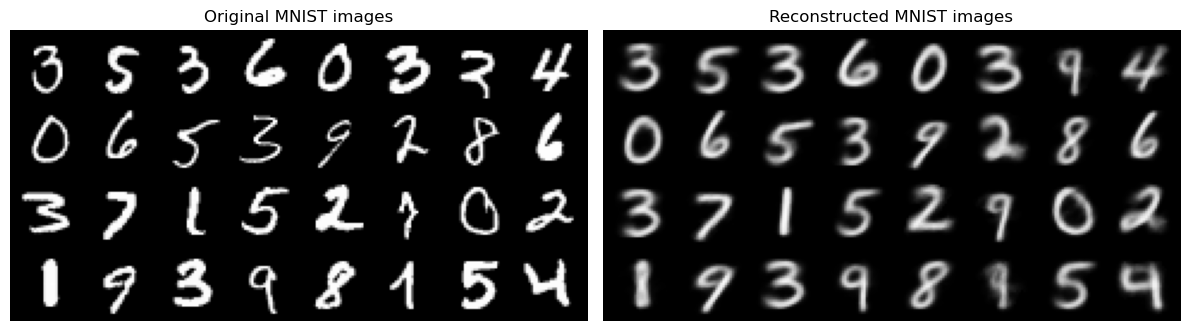

Epoch 10: 0.03349454657855763
Epoch 11: 0.03311327798192753
Epoch 12: 0.033011318903281364
Epoch 13: 0.03282738372739127
Epoch 14: 0.032597580033022835


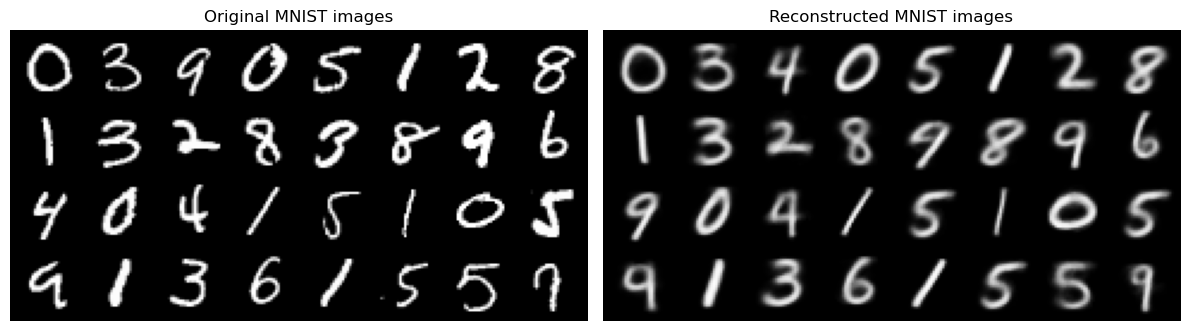

Epoch 15: 0.0324243029305485
Epoch 16: 0.032278446758638564
Epoch 17: 0.03207028848029721
Epoch 18: 0.03197056683562775
Epoch 19: 0.031908069123654986


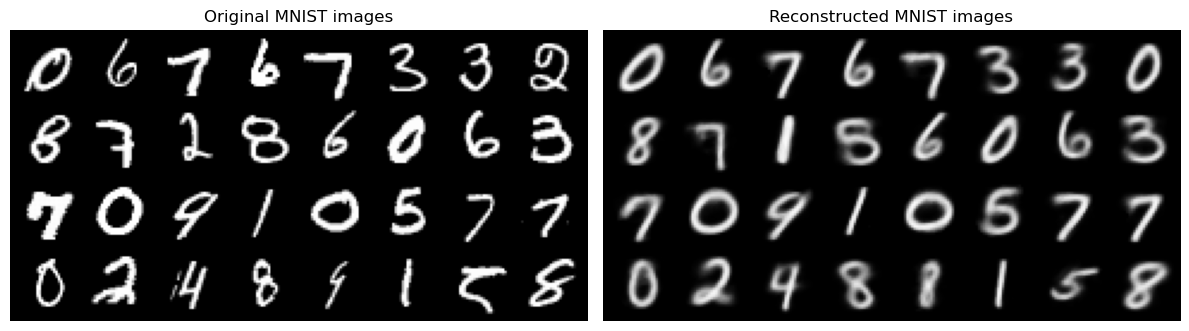

Epoch 20: 0.031687314209065585
Epoch 21: 0.03163180701228093
Epoch 22: 0.03145574382555955
Epoch 23: 0.03131744152169301
Epoch 24: 0.03127063753833966


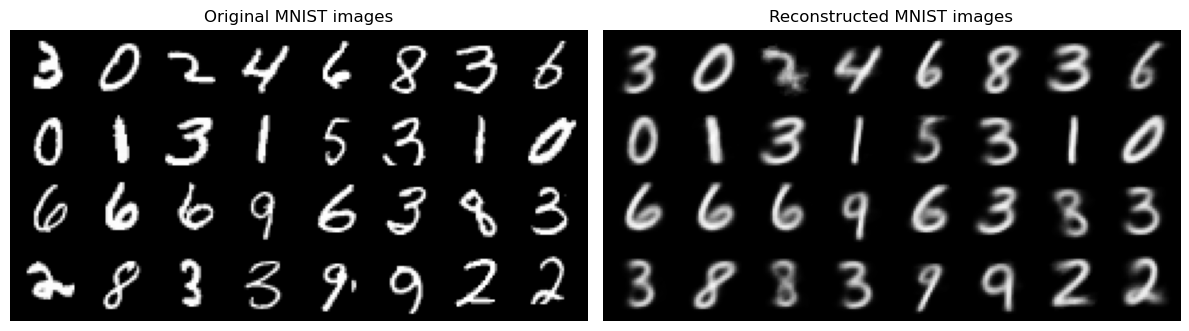

Epoch 25: 0.03115175076440644
Epoch 26: 0.030985312002188743
Epoch 27: 0.030976949350983857
Epoch 28: 0.030783486993375745
Epoch 29: 0.030703476362073344


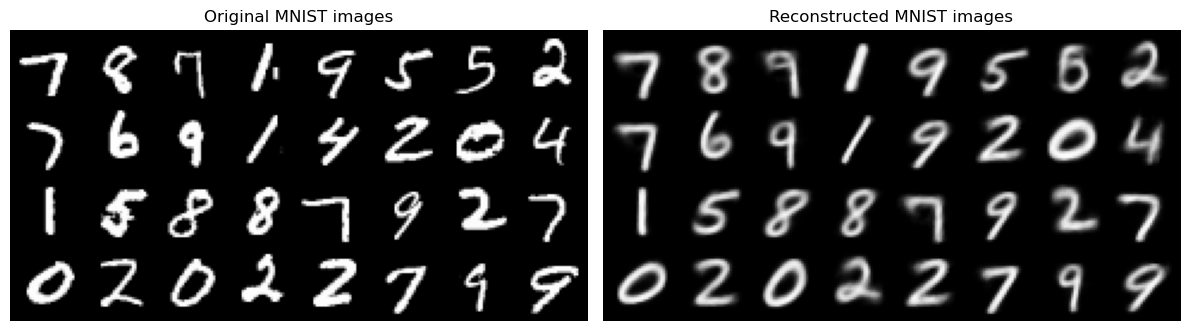

Epoch 30: 0.030715229243897933
Epoch 31: 0.03064164572329854
Epoch 32: 0.030664362863246312
Epoch 33: 0.030730011495652357
Epoch 34: 0.030697216804045985


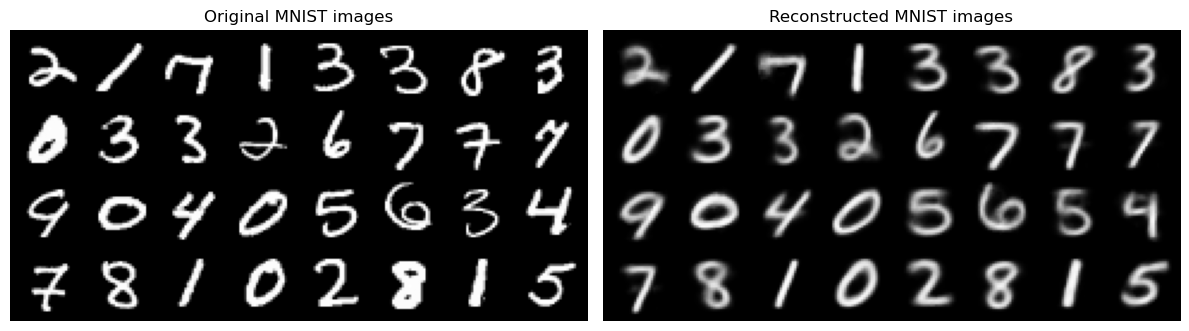

Epoch 35: 0.030712955537984876
Epoch 36: 0.030515288955954983
Epoch 37: 0.030443199534914388
Epoch 38: 0.03036451783142428
Epoch 39: 0.030266859078172174


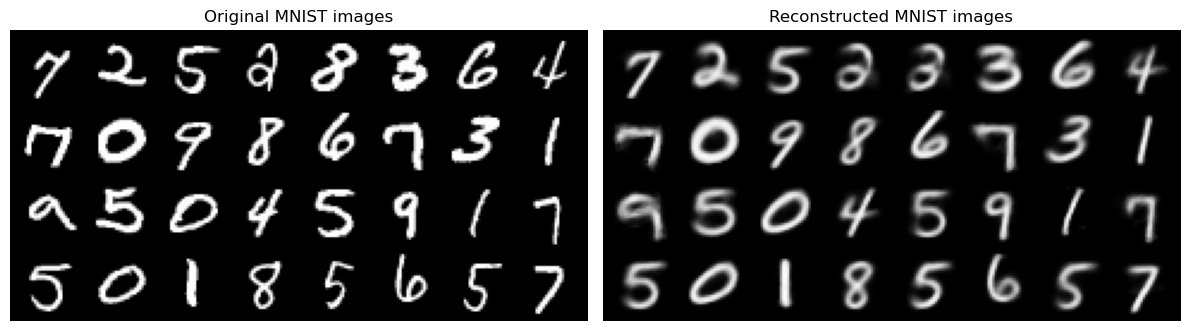

Epoch 40: 0.03009591203556259
Epoch 41: 0.03011188124105938
Epoch 42: 0.029897864236792266
Epoch 43: 0.029825113757428075
Epoch 44: 0.029930770975043142


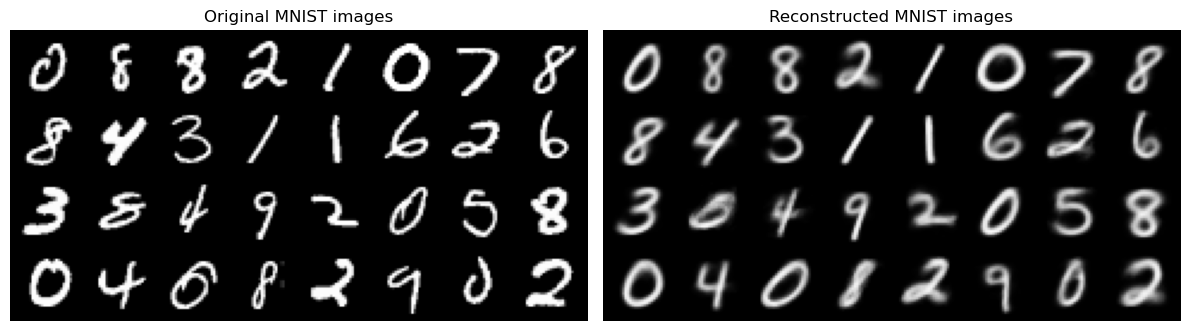

Epoch 45: 0.029860526793944176
Epoch 46: 0.029688786079825114
Epoch 47: 0.02955574509518932
Epoch 48: 0.02953933279063783
Epoch 49: 0.029469329115154267


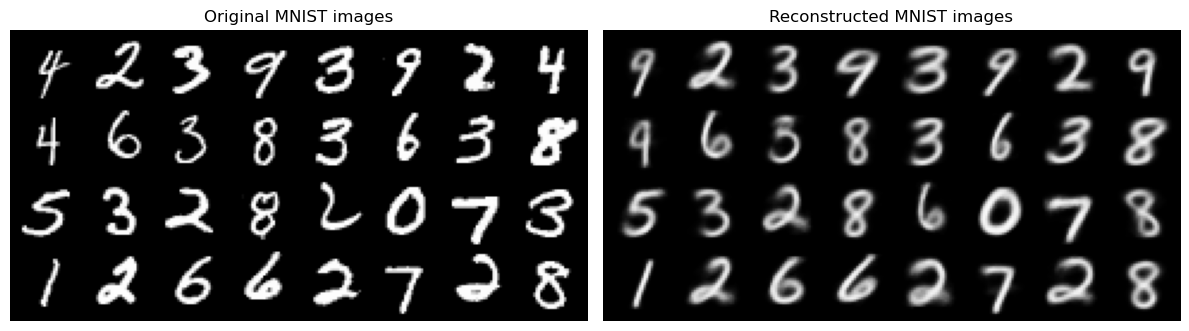

In [21]:
lr = 1e-3
dae = DAE(models).to(DEVICE)
loss = nn.MSELoss()
optimizer = optim.Adam(dae.parameters(), lr)
num_epochs = 50

# train
for epoch in range(num_epochs):
    losses = []
    for i, data_list in enumerate(train_dl_flat): 
        data = data_list[0].to(DEVICE)
        v_pred = dae(data)
        batch_loss = loss(data, v_pred) # difference between actual and reconstructed   
        losses.append(batch_loss.item())
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
    running_loss = np.mean(losses)
    print(f"Epoch {epoch}: {running_loss}")

    if (epoch + 1) % 5 == 0:
        img0 = make_grid(data.view(data.shape[0], 1, dim1, dim2).detach().cpu())
        np0  = np.transpose(img0.numpy(), (1, 2, 0))
        img1 = make_grid(v_pred.view(v_pred.shape[0], 1, dim1, dim2).detach().cpu())
        np1  = np.transpose(img1.numpy(), (1, 2, 0))
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        axes[0].imshow(np0)
        axes[0].set_title("Original MNIST images")
        axes[0].axis("off")
        
        axes[1].imshow(np1)
        axes[1].set_title("Reconstructed MNIST images")
        axes[1].axis("off")
        
        plt.tight_layout()
        plt.show()

### 9. Plot Learned 2d Representations

#### 9.1 two-dimensional reprersentations of DAE

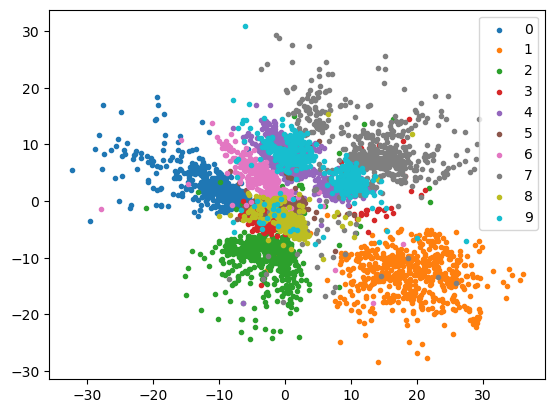

In [23]:
# test_ds: torchvision.datasets.MNIST(..., train=False, ...)
flat_test_input = test_ds.data.view(-1, 28*28).float().div(255).numpy()  # [N,784]
test_labels     = test_ds.targets.numpy()  # [N]

transformed = dae.encode(torch.Tensor(flat_test_input[0:5000]).to(DEVICE)).detach().cpu().numpy()

digit_to_color = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
                      "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
xs = np.array([x[0] for x in transformed])
ys = np.array([x[1] for x in transformed])

fig, ax = plt.subplots()
labels_to_show = test_labels[0:len(transformed)]
for digit in range(10):
    ix = np.where(labels_to_show == digit)
    ax.scatter(xs[ix], ys[ix], c=digit_to_color[digit],
               label=digit, marker=".")
ax.legend()
plt.show()

#### 9.2 two-dimensional reprersentations of PCA

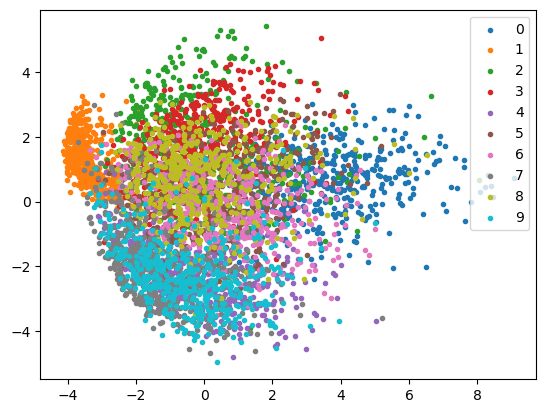

In [28]:
flat_train_input = train_ds.data.view(-1, 784).float().div(255).numpy()
train_labels     = train_ds.targets.numpy()

flat_test_input  = test_ds.data.view(-1, 784).float().div(255).numpy()
test_labels      = test_ds.targets.numpy()

pca = PCA(n_components=2, random_state=10)
pca.fit(flat_train_input)
transformed = pca.transform(flat_test_input[0:5000])

digit_to_color = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
                      "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
xs = np.array([x[0] for x in transformed])
ys = np.array([x[1] for x in transformed])

fig, ax = plt.subplots()
labels_to_show = test_labels[0:len(transformed)]
for digit in range(10):
    ix = np.where(labels_to_show == digit)
    ax.scatter(xs[ix], ys[ix], c=digit_to_color[digit],
               label=digit, marker=".")
ax.legend()
plt.show()

#### 9.3 two-dimensional reprersentations of Naive-DAE

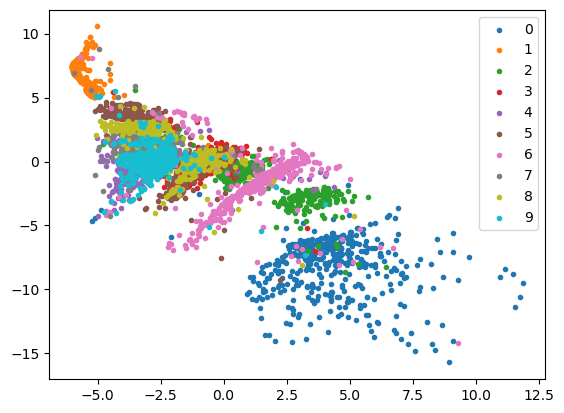

In [30]:
transformed = vanilla_ae.encode(torch.Tensor(flat_test_input[0:5000]).to(DEVICE)).detach().cpu().numpy()

digit_to_color = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
                      "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
xs = np.array([x[0] for x in transformed])
ys = np.array([x[1] for x in transformed])

fig, ax = plt.subplots()
labels_to_show = test_labels[0:len(transformed)]
for digit in range(10):
    ix = np.where(labels_to_show == digit)
    ax.scatter(xs[ix], ys[ix], c=digit_to_color[digit],
               label=digit, marker=".")
ax.legend()
plt.show()